In [7]:
print('MARKER: EOFTCMESO - FIRST CELL')


MARKER: EOFTCMESO - FIRST CELL


In [8]:
import xarray as xr 
import numpy as np 
import matplotlib.pyplot as plt
import cmaps as cmap 
import scipy 

fulldataset = xr.open_dataset(r"C:\Users\deela\Downloads\mel1028netcdfv2.nc")
dataset = fulldataset.sel(time = slice(np.datetime64('2025-10-28T18')), radius = slice(0, 200))
print(dataset)

<xarray.Dataset> Size: 347MB
Dimensions:    (time: 1080, radius: 201, theta: 200)
Coordinates:
  * time       (time) datetime64[ns] 9kB 2025-10-28 ... 2025-10-28T17:59:00
  * radius     (radius) int64 2kB 0 1 2 3 4 5 6 ... 194 195 196 197 198 199 200
  * theta      (theta) float64 2kB -3.136 -3.105 -3.073 ... 3.078 3.11 3.142
Data variables:
    data       (time, radius, theta) float64 347MB ...
    latitude   (time) float64 9kB ...
    EyeRad     (time) float64 9kB ...
    EyeTmp     (time) float64 9kB ...
    MinTmpRad  (time) float64 9kB ...
    CDOTmp     (time) float64 9kB ...
    CDORad     (time) float64 9kB ...
    CDOStd     (time) float64 9kB ...
    MinStd     (time) float64 9kB ...
    MaxStd     (time) float64 9kB ...
    longitude  (time) float64 9kB ...


In [9]:
t = '06'
mean = dataset['data'].sel(time = slice(np.datetime64(f'2025-10-28T{str(int(t) - 3).zfill(2)}'), np.datetime64(f'2025-10-28T{t}'))).mean('time')
stdv = dataset['data'].sel(time = slice(np.datetime64(f'2025-10-28T{str(int(t) - 3).zfill(2)}'), np.datetime64(f'2025-10-28T{t}'))).std('time')
frame = dataset['data'].sel(time = np.datetime64(f'2025-10-28T{t}'))
anom = (frame - mean) / stdv

(1080, 500, 200)


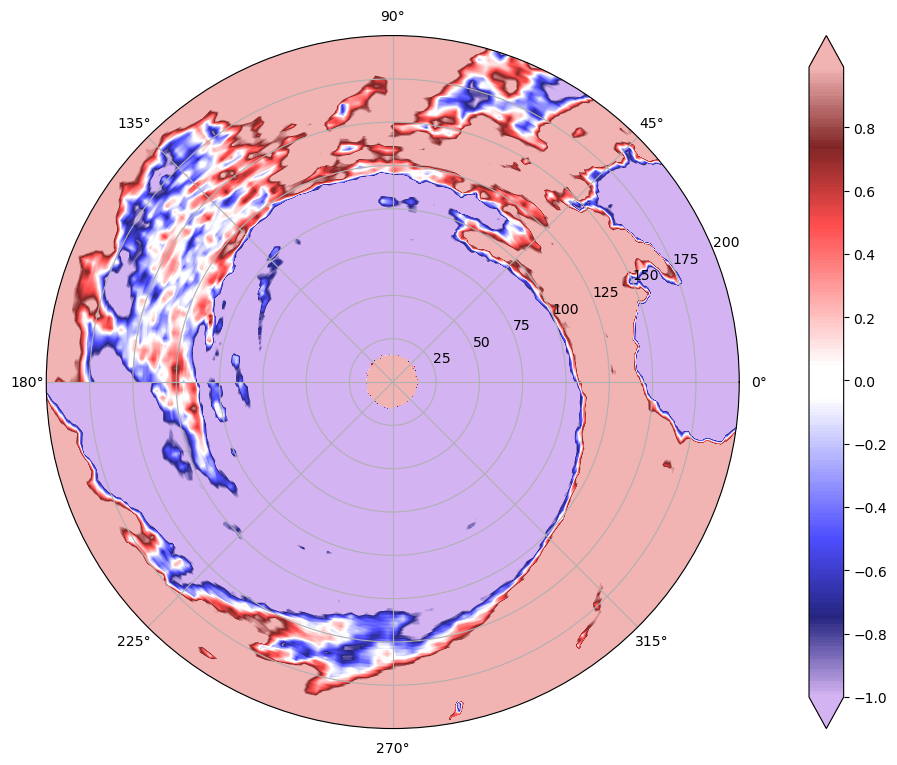

In [10]:
import satcmaps as scmp 
from scipy.ndimage import gaussian_filter1d, gaussian_filter

plt.figure(figsize = (18, 9))
plt.subplot(projection = 'polar')
print(fulldataset['data'].values.shape)
plt.contourf(dataset.theta, dataset.radius, frame - gaussian_filter(frame, sigma = 30), levels = np.arange(-1, 1, 0.01), extend = 'both', cmap = cmap.tempAnoms3())
plt.colorbar()
plt.show()

c:\Users\deela\anaconda3\envs\Env5252025\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


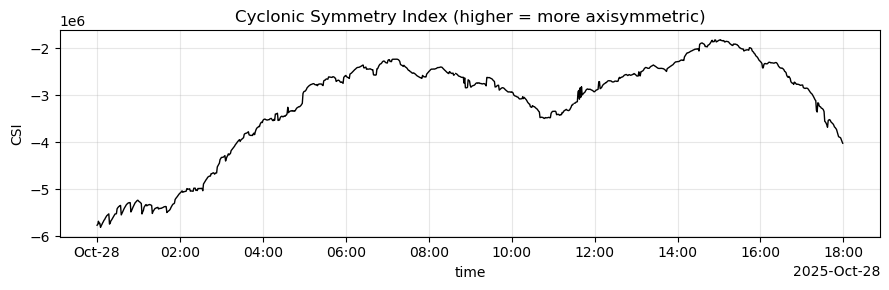

In [11]:
# Diagnostic: Cyclonic Symmetry Index (CSI) time series
# CSI = 1 - (azimuthal std / azimuthal mean), averaged over radius
if 'data' not in dataset:
    raise KeyError("Dataset must include variable 'data'.")

# Ensure we only use positive mean to avoid division issues
mean_theta = dataset['data'].mean('theta')
std_theta = dataset['data'].std('theta')
ratio = (std_theta / mean_theta.clip(min=1e-6))
csi = 1 - ratio.mean('radius')

fig, ax = plt.subplots(figsize=(9, 3))
csi.plot(ax=ax, color='black', lw=1)
ax.set_title('Cyclonic Symmetry Index (higher = more axisymmetric)')
ax.set_ylabel('CSI')
ax.grid(True, alpha=0.3)
plt.tight_layout()


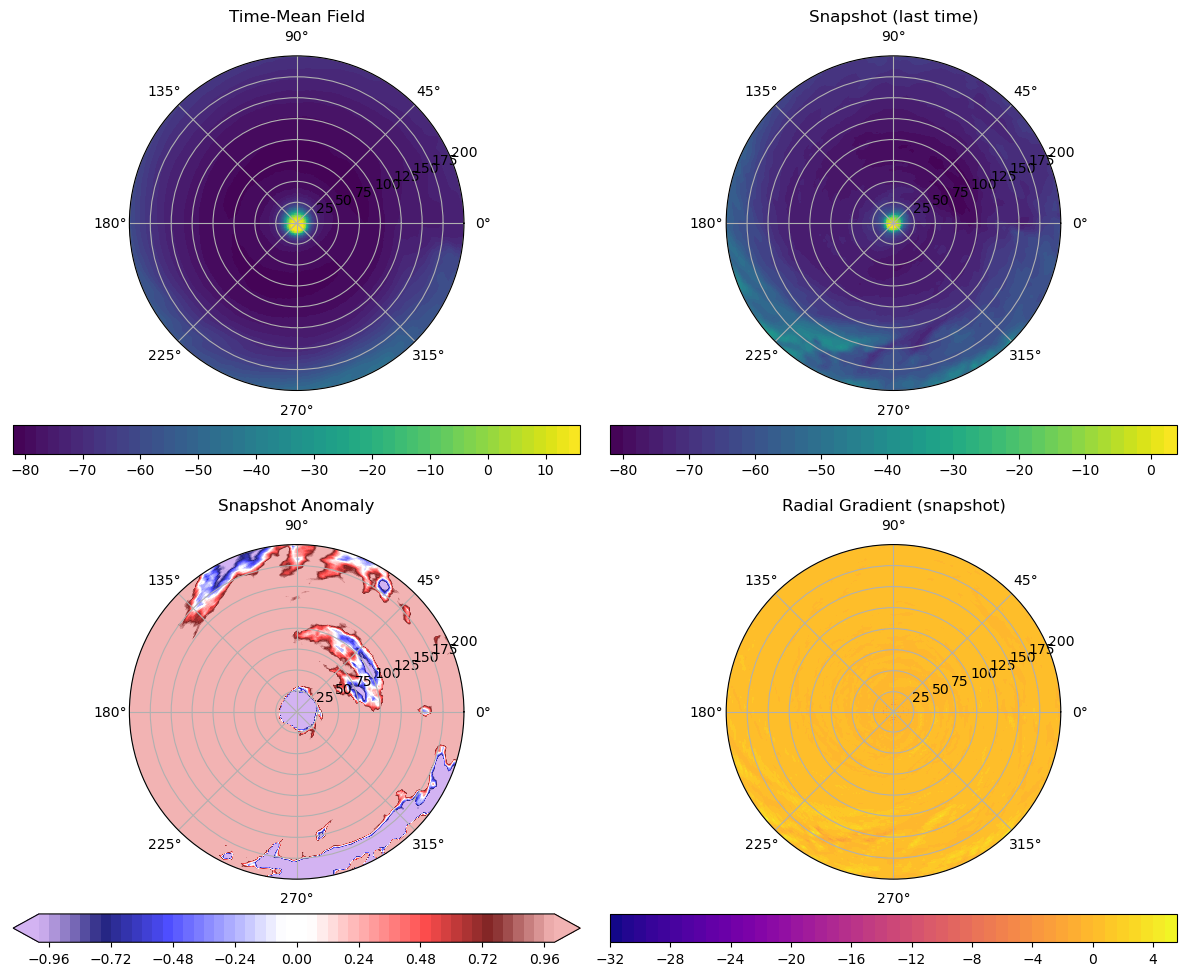

In [12]:
# === NEW MULTIPANEL DIAGNOSTIC (APPENDED LAST) ===
data = dataset['data']
mean_field = data.mean('time')
snapshot = data.isel(time=-1)
anom_field = snapshot - mean_field

# Radial gradient of snapshot (first-order)
grad_r = snapshot.diff('radius')

fig, axs = plt.subplots(2, 2, subplot_kw={'projection': 'polar'}, figsize=(12, 10))
axs = axs.ravel()

cf0 = axs[0].contourf(dataset.theta, dataset.radius, mean_field, levels=50, cmap='viridis')
axs[0].set_title('Time-Mean Field')
fig.colorbar(cf0, ax=axs[0], orientation='horizontal', pad=0.08)

cf1 = axs[1].contourf(dataset.theta, dataset.radius, snapshot, levels=50, cmap='viridis')
axs[1].set_title('Snapshot (last time)')
fig.colorbar(cf1, ax=axs[1], orientation='horizontal', pad=0.08)

cf2 = axs[2].contourf(dataset.theta, dataset.radius, anom_field, levels=np.linspace(-1, 1, 51), cmap=cmap.tempAnoms3(), extend='both')
axs[2].set_title('Snapshot Anomaly')
fig.colorbar(cf2, ax=axs[2], orientation='horizontal', pad=0.08)

# For diff, radius length is one shorter; trim theta/radius to match
r_grad = dataset.radius.isel(radius=slice(1, None))
cf3 = axs[3].contourf(dataset.theta, r_grad, grad_r, levels=50, cmap='plasma')
axs[3].set_title('Radial Gradient (snapshot)')
fig.colorbar(cf3, ax=axs[3], orientation='horizontal', pad=0.08)

plt.tight_layout()


In [13]:
print('MARKER: EOFTCMESO - APPENDED AGAIN')


MARKER: EOFTCMESO - APPENDED AGAIN
